In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import dataloader as dl
import torch.optim as SGD
import numpy as np

Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])


Softmax Regression

In [2]:
class Softmax_Regression_from_scratch():
    def __init__(self, input_size, num_classes):
        self.w = nn.Parameter(torch.randn(input_size, num_classes) * 0.01, requires_grad=True)
        self.b = torch.zeros(num_classes, requires_grad=True)
        
        
        
        self.validation_losses = []
        self.training_losses = []
        self.validation_accuracies = []
        self.training_accuracies = []
        
    def softmax(self, z):
        exp_z = torch.exp(z)
        return exp_z / torch.sum(exp_z, dim=1, keepdim=True)
    
    def cross_entropy_loss(self, y_true_indices, y_pred_softmax):
        num_samples = y_true_indices.shape[0]
        correct_class_probs = y_pred_softmax[range(num_samples), y_true_indices]
        epsilon = 1e-9
        loss = -torch.log(correct_class_probs + epsilon)
        return torch.mean(loss)
    
    def forward_pass(self, x):
        logits = x @ self.w + self.b
        y_pred_softmax = self.softmax(logits)
        return y_pred_softmax
    
    
    def train(self, learning_rate, no_epochs, train_loader, val_loader):        
        ## training phase
        for epoch in range(no_epochs):
            train_loss = 0
            val_losses = 0
            train_accuracy = 0
            val_accuracy = 0
            for data, target in train_loader:
                
                y_pred = self.forward_pass(data)
                loss = self.cross_entropy_loss(target, y_pred)
                
                train_accuracy += self.calculate_accuracy(target, y_pred)
                train_loss += loss.item()
                
                loss.backward()
                
                with torch.no_grad():
                    self.w -= learning_rate * self.w.grad
                    self.b -= learning_rate * self.b.grad
                    
                    self.w.grad.zero_()
                    self.b.grad.zero_()
                    
            ## Validation Phase        
            with torch.no_grad():
                for val_data, val_target in val_loader:
                    val_pred = self.forward_pass(val_data)
                    
                    val_accuracy += self.calculate_accuracy(val_target, val_pred)
                    val_loss = self.cross_entropy_loss(val_target, val_pred)
                    
                    val_losses += val_loss.item()
                    
            self.training_accuracies.append(train_accuracy / len(train_loader))
            self.validation_accuracies.append(val_accuracy / len(val_loader))
            
            avg_train_loss = train_loss / len(train_loader)
            avg_val_loss = val_losses / len(val_loader)
            
            self.training_losses.append(avg_train_loss)
            self.validation_losses.append(avg_val_loss)
            
            print(f'Epoch {epoch+1}/{no_epochs}')
            print(f'  Train Loss: {avg_train_loss:.4f} | Train Acc: {self.training_accuracies[epoch]:.2f}%')
            print(f'  Val Loss: {avg_val_loss:.4f}   | Val Acc: {self.validation_accuracies[epoch]:.2f}%')
        
    def predict(self, x):
        with torch.no_grad():
            y_pred = self.forward_pass(x)
            predicted_labels = torch.argmax(y_pred, dim=1)
        return predicted_labels
    
    def calculate_accuracy(self, y_true_indices, y_pred_softmax):
        predicted_labels = torch.argmax(y_pred_softmax, dim=1)
        correct = (predicted_labels == y_true_indices).sum().item()
        return (correct / y_true_indices.shape[0]) * 100

Configuration

In [3]:
Learning_rate = 0.01
no_epochs = 30
input_size = 28 * 28
num_classes = 10

Training the model

In [4]:
model = Softmax_Regression_from_scratch(input_size, num_classes)
model.train(Learning_rate, no_epochs, dl.train_loader_linear, dl.val_loader_linear)

Epoch 1/30
  Train Loss: 1.1707 | Train Acc: 79.11%
  Val Loss: 0.7642   | Val Acc: 83.66%
Epoch 2/30
  Train Loss: 0.6553 | Train Acc: 85.58%
  Val Loss: 0.5885   | Val Acc: 86.00%
Epoch 3/30
  Train Loss: 0.5442 | Train Acc: 86.99%
  Val Loss: 0.5167   | Val Acc: 86.78%
Epoch 4/30
  Train Loss: 0.4908 | Train Acc: 87.70%
  Val Loss: 0.4764   | Val Acc: 87.65%
Epoch 5/30
  Train Loss: 0.4580 | Train Acc: 88.21%
  Val Loss: 0.4493   | Val Acc: 88.09%
Epoch 6/30
  Train Loss: 0.4356 | Train Acc: 88.53%
  Val Loss: 0.4305   | Val Acc: 88.47%
Epoch 7/30
  Train Loss: 0.4184 | Train Acc: 88.81%
  Val Loss: 0.4156   | Val Acc: 88.73%
Epoch 8/30
  Train Loss: 0.4054 | Train Acc: 89.07%
  Val Loss: 0.4039   | Val Acc: 89.00%
Epoch 9/30
  Train Loss: 0.3944 | Train Acc: 89.28%
  Val Loss: 0.3947   | Val Acc: 89.05%
Epoch 10/30
  Train Loss: 0.3857 | Train Acc: 89.51%
  Val Loss: 0.3865   | Val Acc: 89.25%
Epoch 11/30
  Train Loss: 0.3780 | Train Acc: 89.70%
  Val Loss: 0.3797   | Val Acc: 89.5

Training vs Validation loss

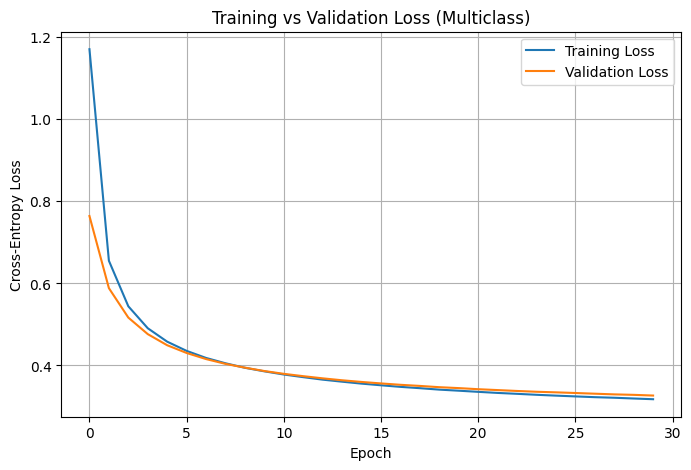

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(model.training_losses, label='Training Loss')
plt.plot(model.validation_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Training vs Validation Loss (Multiclass)')
plt.legend()
plt.grid(True)
plt.show()


Test vs validation accuracy

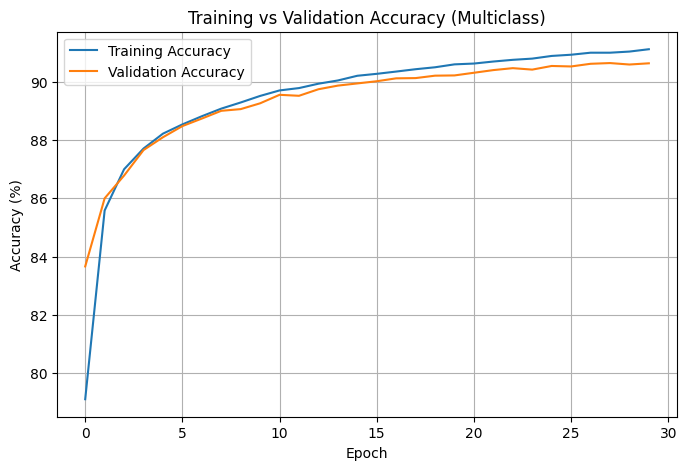

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(model.training_accuracies, label='Training Accuracy')
plt.plot(model.validation_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training vs Validation Accuracy (Multiclass)')
plt.legend()
plt.grid(True)
plt.show()

test set evaluation and confusion matrix

In [7]:
print("\n--- Evaluating on Test Set ---")
accuracy = 0
all_targets = []
all_predictions = []

with torch.no_grad(): 
    for data, target in dl.test_loader_linear:
        prediction = model.predict(data) # Gets predicted class indices
        correct = (prediction == target).sum().item()
        total = target.shape[0]
        accuracy += (correct / total) * 100
        all_targets.extend(target.numpy())
        all_predictions.extend(prediction.numpy())
        
test_accuracy = accuracy / len(dl.test_loader_linear)
print(f'Average Test Accuracy over all batches: {test_accuracy:.2f}%')
matrix = confusion_matrix(np.array(all_targets), np.array(all_predictions))
print("\nConfusion Matrix:")
print(matrix)


--- Evaluating on Test Set ---
Average Test Accuracy over all batches: 90.88%

Confusion Matrix:
[[1136    0    4    1    1   13   11    1   13    5]
 [   0 1292    9   12    1   11    1    3   18    2]
 [  10   10 1033   18   31    7   13   19   39   11]
 [   6    7   35 1067    1   41    8   21   28   12]
 [   0    6    7    1 1080    1    3    1    4   65]
 [  14   13    8   37    9  946   18    4   27    8]
 [  10    6    6    0    6   23 1123    1    9    0]
 [   8   11   15    7   10    1    0 1155    5   41]
 [   4   25    8   28    7   39   10    9 1024   16]
 [  11    8    6   22   34   11    2   40    7 1049]]


per class accuracy

In [8]:
class_accuracy = matrix.diagonal() / matrix.sum(axis=1)
for i, acc in enumerate(class_accuracy):
    print(f'Accuracy for digit {i}: {acc * 100:.2f}%')

Accuracy for digit 0: 95.86%
Accuracy for digit 1: 95.77%
Accuracy for digit 2: 86.73%
Accuracy for digit 3: 87.03%
Accuracy for digit 4: 92.47%
Accuracy for digit 5: 87.27%
Accuracy for digit 6: 94.85%
Accuracy for digit 7: 92.18%
Accuracy for digit 8: 87.52%
Accuracy for digit 9: 88.15%


# Built-in implementaion of Softmax Regression

In [9]:
class SoftmaxRegressionTorch(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.linear = nn.Linear(input_size, num_classes)
    def forward(self, x):
        return self.linear(x)

torch_model = SoftmaxRegressionTorch(input_size, num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = SGD.SGD(torch_model.parameters(), lr=Learning_rate)

for epoch in range(no_epochs):
    for data, target in dl.train_loader_linear:
        optimizer.zero_grad()
        output = torch_model(data)
        loss = criterion(output, target)

        loss.backward()
        optimizer.step()


In [10]:
accuracy_list = []
with torch.no_grad():  
    correct = 0
    total = 0
    for images, labels in dl.test_loader_linear:
        images = images.reshape(-1, input_size)
        outputs = torch_model(images)
        _, predicted = torch.max(outputs.data, 1) 
        accuracy = Softmax_Regression_from_scratch.calculate_accuracy(None, labels, torch.softmax(outputs, dim=1))
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        accuracy_list.append(accuracy)
        
    avg_accuracy = sum(accuracy_list) / len(accuracy_list)

    print(f'Accuracy of the model on the test images: {avg_accuracy}%')

Accuracy of the model on the test images: 90.94082446808511%
